#### Case opti-4: Isobaric evaporation of ammonia in a large tank for long-term storage


In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti_jax

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import JAX library
import jax
import jax.numpy as jnp

# Import time
import time

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)


#### Setup tank and cryogen properties

In [2]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K

V_tank = 800 # Tank volume / m^3

a   = 1
d_i = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.026  # W/m2/K
U_V = 0.026  # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.3

# Specify tank operating pressure
P = 100000 # Pa

# Set fixed bottom flux heat 
q_b_fixed = 100/(np.pi*((8**2)/4)) # W/m2

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = q_b_fixed, Q_roof = 0, eta_w = 0.90)

# # Initialise cryogen
cryogen = Cryogen(name = "nitrogen")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))
# comparison of heat flux
print("q_b used: ", q_b_fixed, " q_b free: ", U_L*(T_air - cryogen.T_sat))
print("Q_b used: ", large_tank.Q_b, " Q_b free: ", U_L*(T_air - cryogen.T_sat)*(np.pi*((d_i**2)/4)))

The initial evaporation rate of nitrogen is 34.2 kg/h
q_b used:  1.9894367886486917  q_b free:  5.743569007001908
Q_b used:  158.18067693214047  Q_b free:  456.67278232606196


Calculate initial evaporation rate and transient period

In [3]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of nitrogen is 34.2 kg/h
Transient period = 537911.572 s 
Simulation time: 150 h
BOR = 0.423 %


#### Simulation setup and execution

In [4]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 720

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
# large_tank.evaporate(evap_time)

In [5]:
opti = Opti_jax(large_tank)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


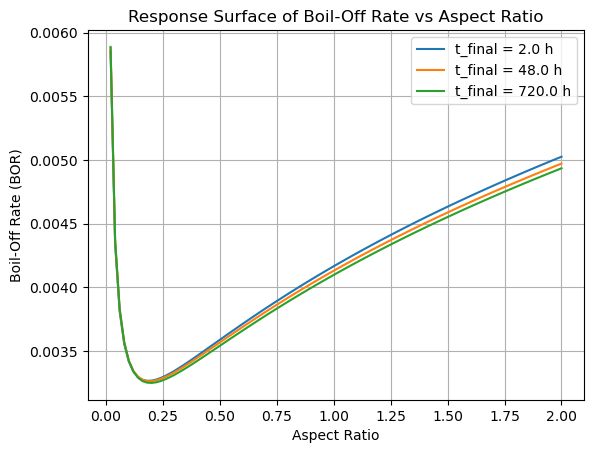

In [6]:
opti.plot_surface_response(jnp.linspace(0.02, 2, 100), 2*3600)
opti.plot_surface_response(jnp.linspace(0.02, 2, 100), 48*3600)
opti.plot_surface_response(jnp.linspace(0.02, 2, 100), 720*3600)

EquinoxRuntimeError: Above is the stack outside of JIT. Below is the stack inside of JIT:
  File "/home/milcaito/anaconda3/lib/python3.9/site-packages/diffrax/_integrate.py", line 1487, in diffeqsolve
    sol = result.error_if(sol, jnp.invert(is_okay(result)))
equinox.EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.

-------------------

An error occurred during the runtime of your JAX program.

1) Setting the environment variable `EQX_ON_ERROR=breakpoint` is usually the most useful
way to debug such errors. This can be interacted with using most of the usual commands
for the Python debugger: `u` and `d` to move up and down frames, the name of a variable
to print its value, etc.

2) You may also like to try setting `JAX_DISABLE_JIT=1`. This will mean that you can
(mostly) inspect the state of your program as if it was normal Python.

3) See `https://docs.kidger.site/equinox/api/debug/` for more suggestions.


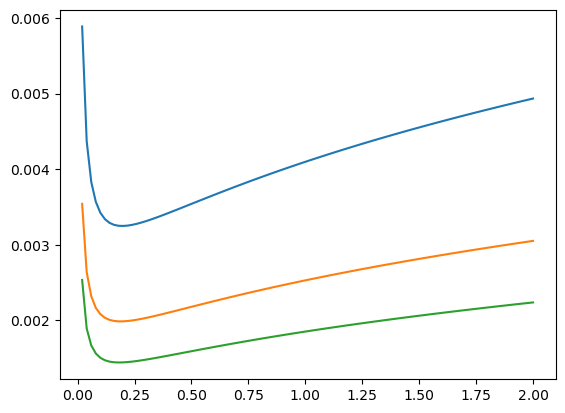

In [7]:
opti.plot_surface_response_liquid_filling(jnp.linspace(0.02, 2, 100), jnp.linspace(0.3, 0.9, 4),720*3600)

In [ ]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=2*3600, coarse_samples=100, fine_samples=1000,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 1.868687, BOR: 7.029184e-03
Phase 2: Fine grid search with 1000 samples...
Refined optimal aspect ratio: 1.856325
Minimum BOR: 7.029149e-03
Tiempo de ejecución: 1.78 segundos


In [ ]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=48*3600, coarse_samples=100, fine_samples=1000,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 1.896970, BOR: 6.985777e-03
Phase 2: Fine grid search with 1000 samples...
Refined optimal aspect ratio: 1.891815
Minimum BOR: 6.985771e-03
Tiempo de ejecución: 2.63 segundos


In [ ]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=720*3600, coarse_samples=100, fine_samples=100,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 1.896970, BOR: 6.967404e-03
Phase 2: Fine grid search with 100 samples...
Refined optimal aspect ratio: 1.906566
Minimum BOR: 6.967384e-03
Tiempo de ejecución: 5.03 segundos


In [ ]:
# optimal_aspect_ratio = opti.optimize(max_iter = 500, t_final = 2 * 3600, lr = 1e-2, x0 = 0, lr_2 = 1e-3, iter_decay_lr=75)
# opti.plot_loss_history()

In [ ]:
opti.optimal_aspect_ratio

Array(0.50505506, dtype=float64)

#### Visualisation of results

#### Vapour temperature

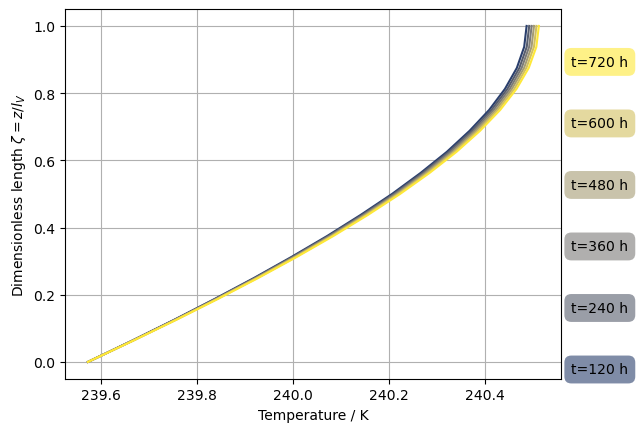

In [ ]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

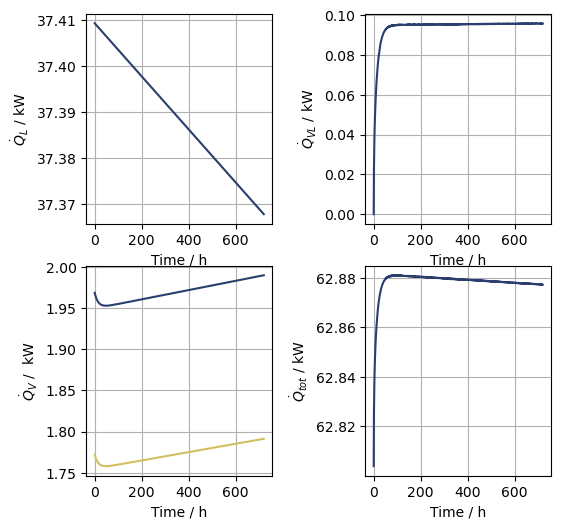

In [ ]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

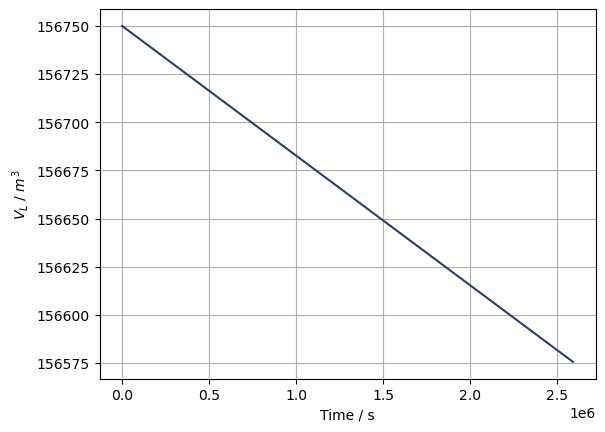

In [ ]:
large_tank.plot_V_L()

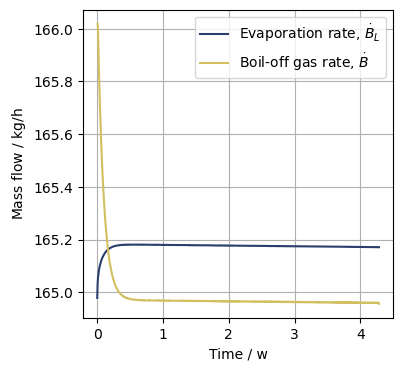

In [ ]:
large_tank.plot_BOG(unit='kg/h', t_unit='w')

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [ ]:
# Import pandas 
import pandas as pd

In [ ]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(large_tank.data)

# Save file to the current working directory
df_evap.to_csv('methane_165000m3.csv')

# Show the first five columns of the dataframe in console
df_evap.head()

In [ ]:
# BOR = (1 - large_tank.data['V_L'][-1]/large_tank.data['V_L'][0])* (86400/large_tank.data['Time'][-1])
BOR = large_tank.BOR()
print("BOR = %.3e %%" % (100 * BOR))

In [ ]:
large_tank.BOR()

In [ ]:
large_tank.data['Time'][-1]

In [ ]:
large_tank.plot_tv_BOG(t_unit='w')

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.